In [1]:
%load_ext autoreload
%autoreload 2

import jax.numpy as jnp
from mGST.reporting.reporting import generate_basis_labels
from mGST.compatibility import std2pp
import matplotlib.pyplot as plt

from mGST.taxonomy import pauli_to_symplectic, symplectic_inner_product, commutation_relation, walsh_hadamard_transform_symplectic, walsh_hadamard_transform_2n_basis, walsh_hadamard_transform_local_basis, weight_histogram
from mGST.visualization import plot_weight_histogram, plot_pauli_probabilities_labeled, plot_pauli_probabilities_indexed

/Users/emiliano.godinez/.pyenv/versions/qcvv-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:2026-04-09 17:12:15,226:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2026-04-09 17:12:15,226 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2026-04-09 17:12:15,228:jax._src.xla_bridge:927: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Users/emiliano.godinez/.pyen

# Load operators

In [2]:
ops_gauge_opt = jnp.load("data/ops_gauge_optimized_mgst_4q_rank_4_all.npz")
ops_target = jnp.load("data/ops_target_mgst_4q_rank_4_all.npz")
ops_gauge_opt.keys(), ops_target.keys()

(KeysView(NpzFile 'data/ops_gauge_optimized_mgst_4q_rank_4_all.npz' with keys: kraus, povm, state),
 KeysView(NpzFile 'data/ops_target_mgst_4q_rank_4_all.npz' with keys: kraus, povm, state))

# Eigenvalues

In [3]:
num_qubits = 4
dim = 2**num_qubits

gate_labels = {0: 'Rx(pi/2)',
 1: 'Rx(pi/2)',
 2: 'Rx(pi/2)',
 3: 'Rx(pi/2)',
 4: 'Ry(pi/2)',
 5: 'Ry(pi/2)',
 6: 'Ry(pi/2)',
 7: 'Ry(pi/2)',
 8: 'CZ-CZ'}

pauli_labels = generate_basis_labels(pdim=dim, basis="Pauli")
len(pauli_labels)

256

In [4]:
kraus_target_pauli, *_ = std2pp(*ops_target.values())
# Convert to pauli basis
kraus_gauge_opt_pauli, *_ = std2pp(*ops_gauge_opt.values())

# Looking only at the last gate (CZ-CZ)
cz_cz_gauge_pauli = kraus_gauge_opt_pauli[-1]
cz_cz_target_pauli = kraus_target_pauli[-1]

cz_cz_gauge_pauli.shape, cz_cz_target_pauli.shape

((256, 256), (256, 256))

In [5]:
pauli_eigenvals_vector = jnp.diag(cz_cz_gauge_pauli)
# what is the sum of its eigenvalues?
jnp.sum(pauli_eigenvals_vector), jnp.linalg.norm(pauli_eigenvals_vector.imag)

(Array(15.98531366+0.j, dtype=complex128), Array(0., dtype=float64))

/Users/emiliano.godinez/.pyenv/versions/qcvv-env/lib/python3.11/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/emiliano.godinez/.pyenv/versions/qcvv-env/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


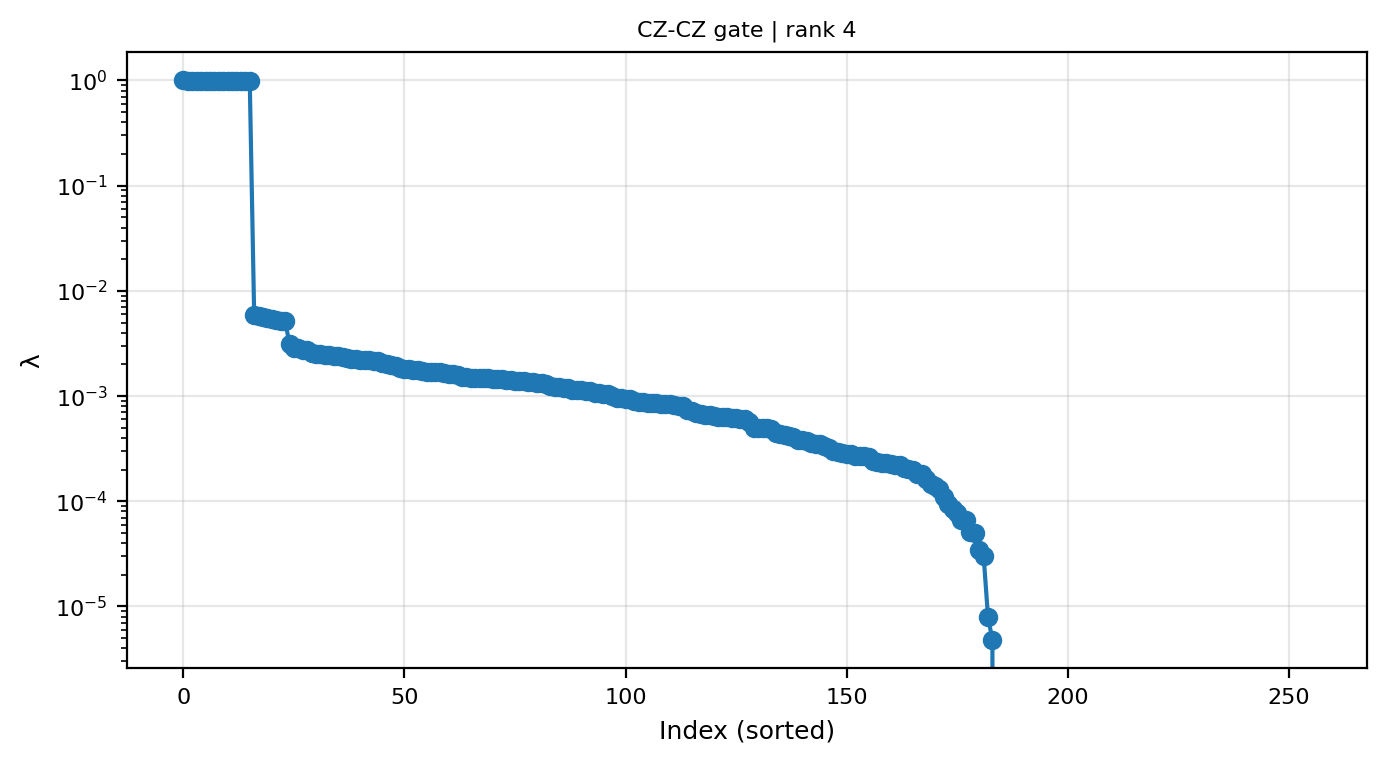

In [6]:
# plotting the eigenvalues
plt.figure(figsize=(8,4), dpi=200)
plt.semilogy(jnp.sort(pauli_eigenvals_vector, descending=True), "o-")
plt.xlabel("Index (sorted)")
plt.ylabel("λ")
plt.title("CZ-CZ gate | rank 4")
plt.grid(alpha=0.3)
plt.show()


# Probabilties

In [7]:
label_1 = "IIXI"
label_2 = "YZZZ"

s1 = pauli_to_symplectic(label_1)
s2 = pauli_to_symplectic(label_2)
symplectic_inner_product(s1, s2)

1

In [8]:
commutation_relation(label_1, label_2)

1

In [9]:
probabilities_dct = walsh_hadamard_transform_symplectic(eigenvalues=pauli_eigenvals_vector.real, pauli_labels=pauli_labels)
probabilities = jnp.array(list(probabilities_dct.values()))

In [10]:
sum(probabilities)

Array(1., dtype=float64)

In [11]:
probabilities_test = walsh_hadamard_transform_2n_basis(pauli_eigenvals_vector.real)
jnp.sum(probabilities_test)

Array(1., dtype=float64)

In [12]:
result_test = walsh_hadamard_transform_local_basis(pauli_eigenvals_vector.real, pauli_labels)
probabilities_test_2 = jnp.array(list(result_test.values()))

In [13]:
jnp.allclose(jnp.sort(probabilities), jnp.sort(probabilities_test)) # not the same if they are not sorted.

Array(True, dtype=bool)

In [14]:
jnp.allclose(probabilities, probabilities_test) # not the same if they are not sorted.

Array(False, dtype=bool)

In [15]:
jnp.allclose(probabilities, probabilities_test_2)

Array(True, dtype=bool)

2026-04-13 15:19:48,408 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode
2026-04-13 15:19:48,477 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode


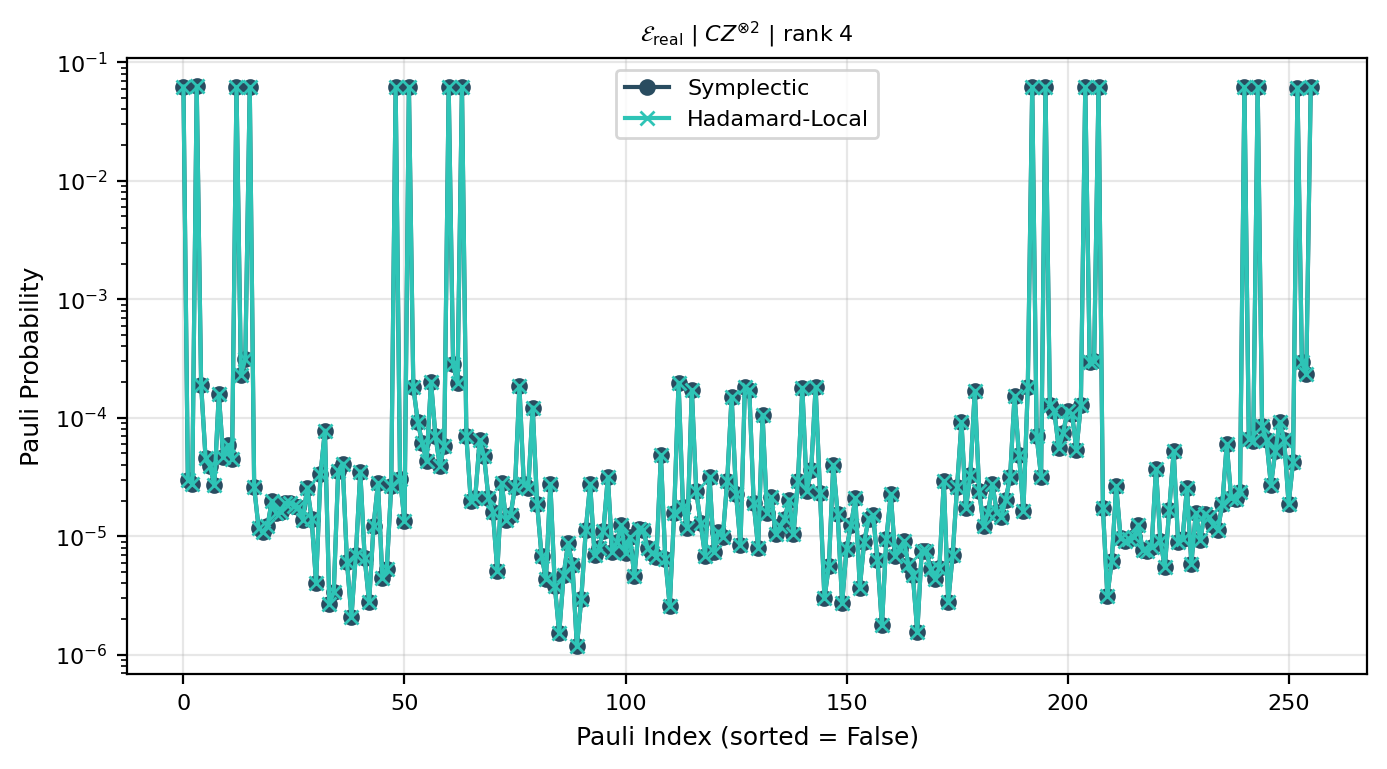

In [46]:
probabilities_by_methods = {
    "Symplectic": probabilities,
    # "Hadamard-Global": probabilities_test,
    "Hadamard-Local": probabilities_test_2
}
title_cz_cz = r"$\mathcal{E}_{\mathrm{real}}$ | $CZ^{\otimes 2}$ | rank 4"
fig_probabilities_cz_cz = plot_pauli_probabilities_indexed(probabilities=probabilities_by_methods, title=title_cz_cz)


In [17]:
hadamard = jnp.array([[1, 1], [1, -1]])
jnp.kron(hadamard, hadamard)

Array([[ 1,  1,  1,  1],
       [ 1, -1,  1, -1],
       [ 1,  1, -1, -1],
       [ 1, -1, -1,  1]], dtype=int64)

# Histogram

2026-04-09 17:12:28,671 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode
2026-04-09 17:12:28,715 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode


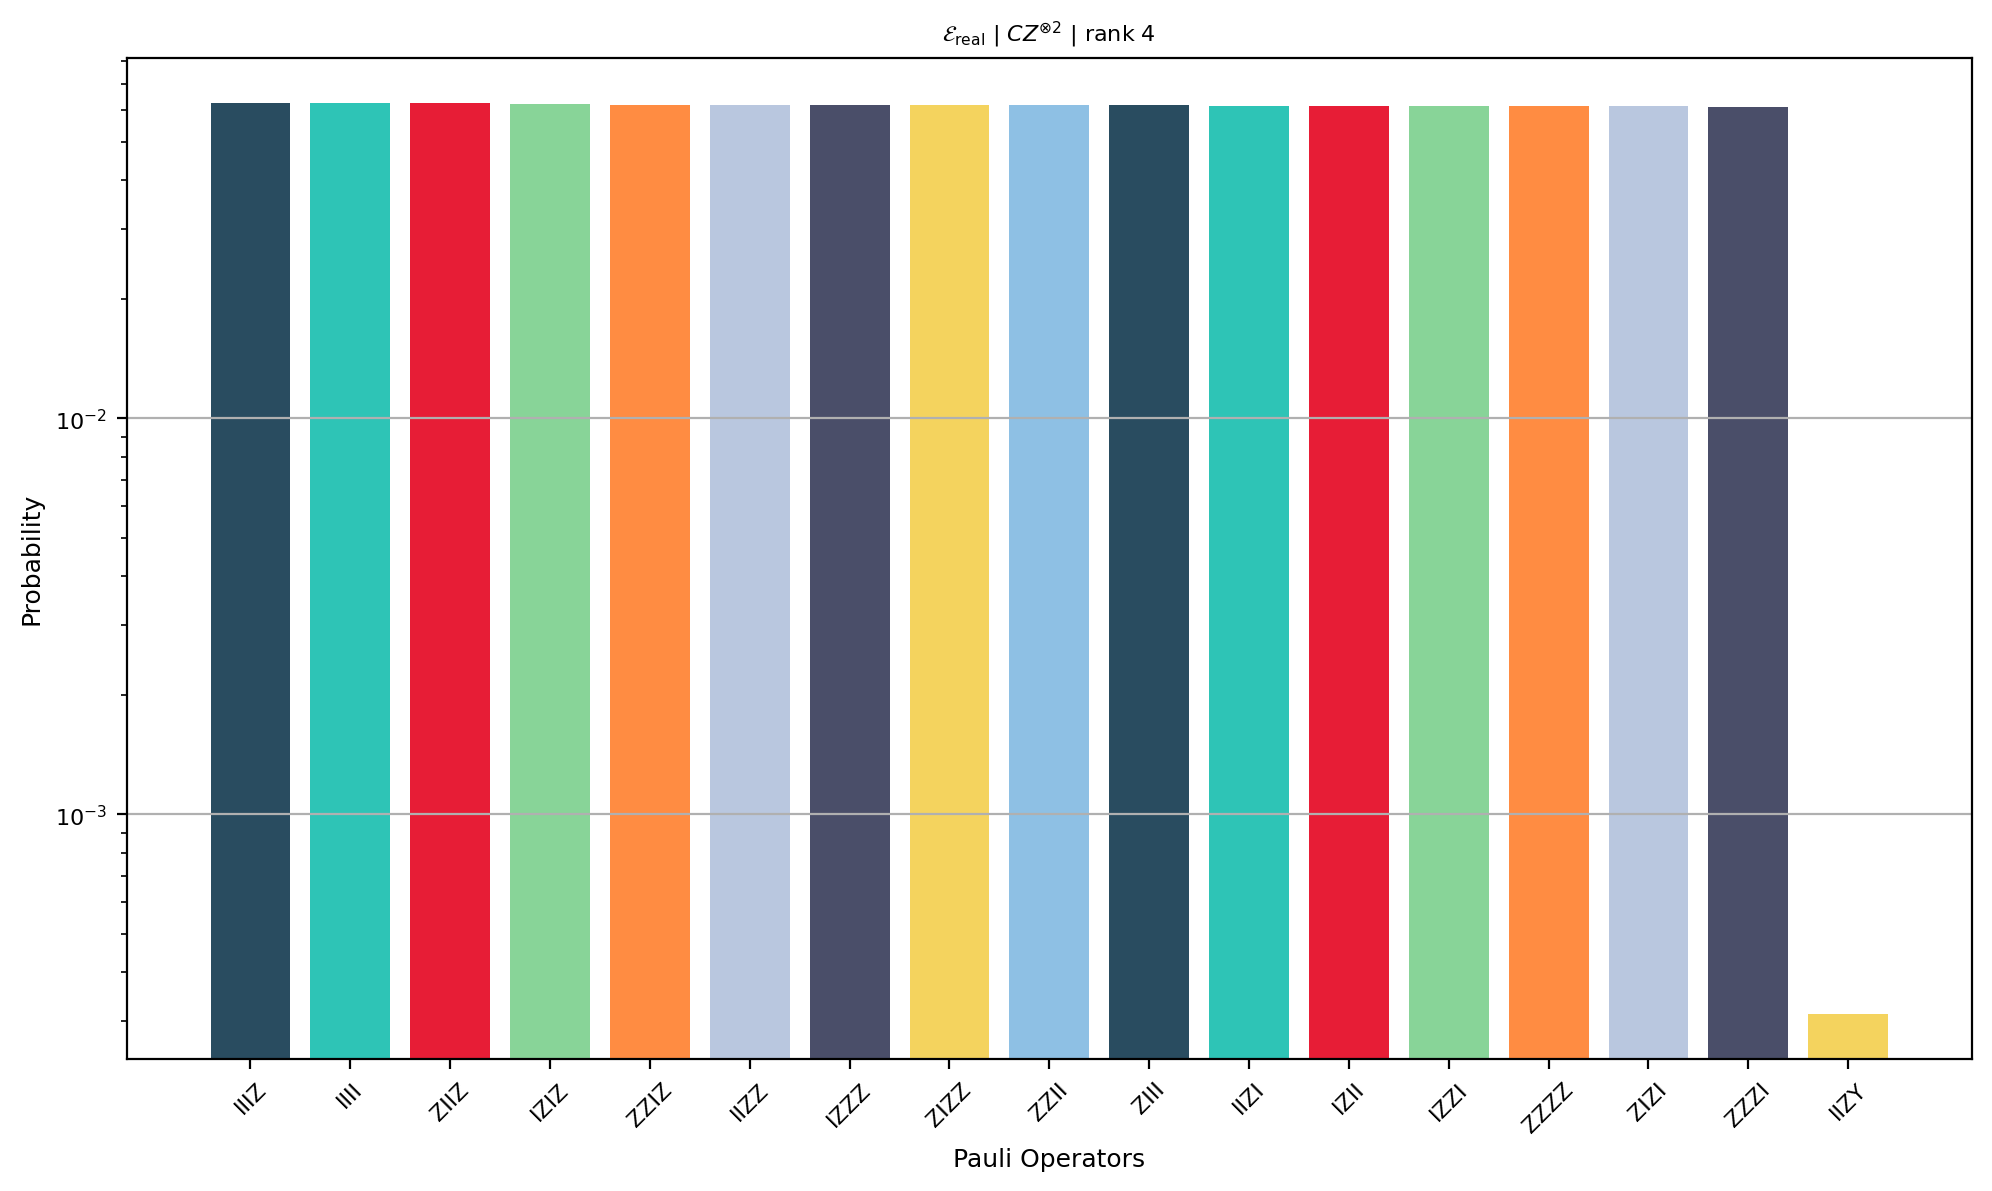

In [18]:
fig_probs_cz_cz_labeled =plot_pauli_probabilities_labeled(probabilities=probabilities_dct, max_num_labels=17, log_scale=True, title=title_cz_cz)

In [19]:
weights = weight_histogram(probabilities_dct, normalize=True)
weights

Total probability: 1.0


{0: Array(0.06244263, dtype=float64),
 1: Array(0.2483852, dtype=float64),
 2: Array(0.37423192, dtype=float64),
 3: Array(0.2515095, dtype=float64),
 4: Array(0.06343074, dtype=float64)}

2026-04-09 17:12:29,800 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode
2026-04-09 17:12:29,837 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode


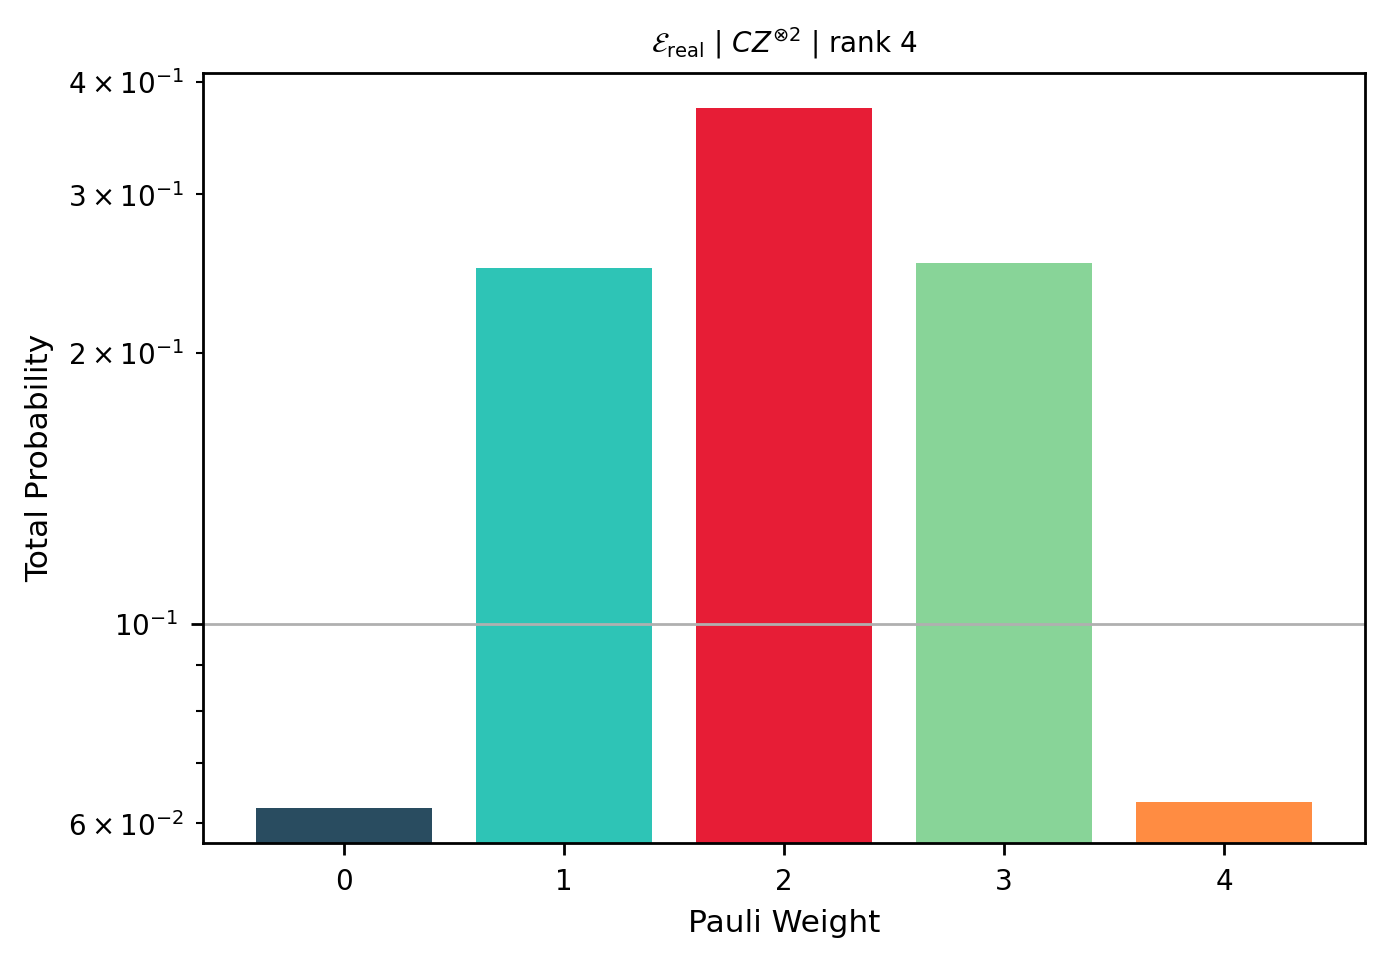

In [20]:
figure_weights = plot_weight_histogram(weights, ascending=True, title=title_cz_cz)

# Now for the effective error channel

In [21]:
cz_cz_target_pauli_inv = jnp.linalg.inv(cz_cz_target_pauli)
error_ptm = cz_cz_gauge_pauli @ cz_cz_target_pauli_inv
error_ptm_eigenvals = jnp.diag(error_ptm)
probabilities_dict_error = walsh_hadamard_transform_local_basis(error_ptm_eigenvals.real, pauli_labels)
probabilties_error = jnp.array(list(probabilities_dict_error.values()))

2026-04-09 17:12:54,725 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode
2026-04-09 17:12:54,729 - matplotlib.mathtext - INFO - Substituting symbol U from STIXNonUnicode
2026-04-09 17:12:54,846 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode
2026-04-09 17:12:54,851 - matplotlib.mathtext - INFO - Substituting symbol U from STIXNonUnicode


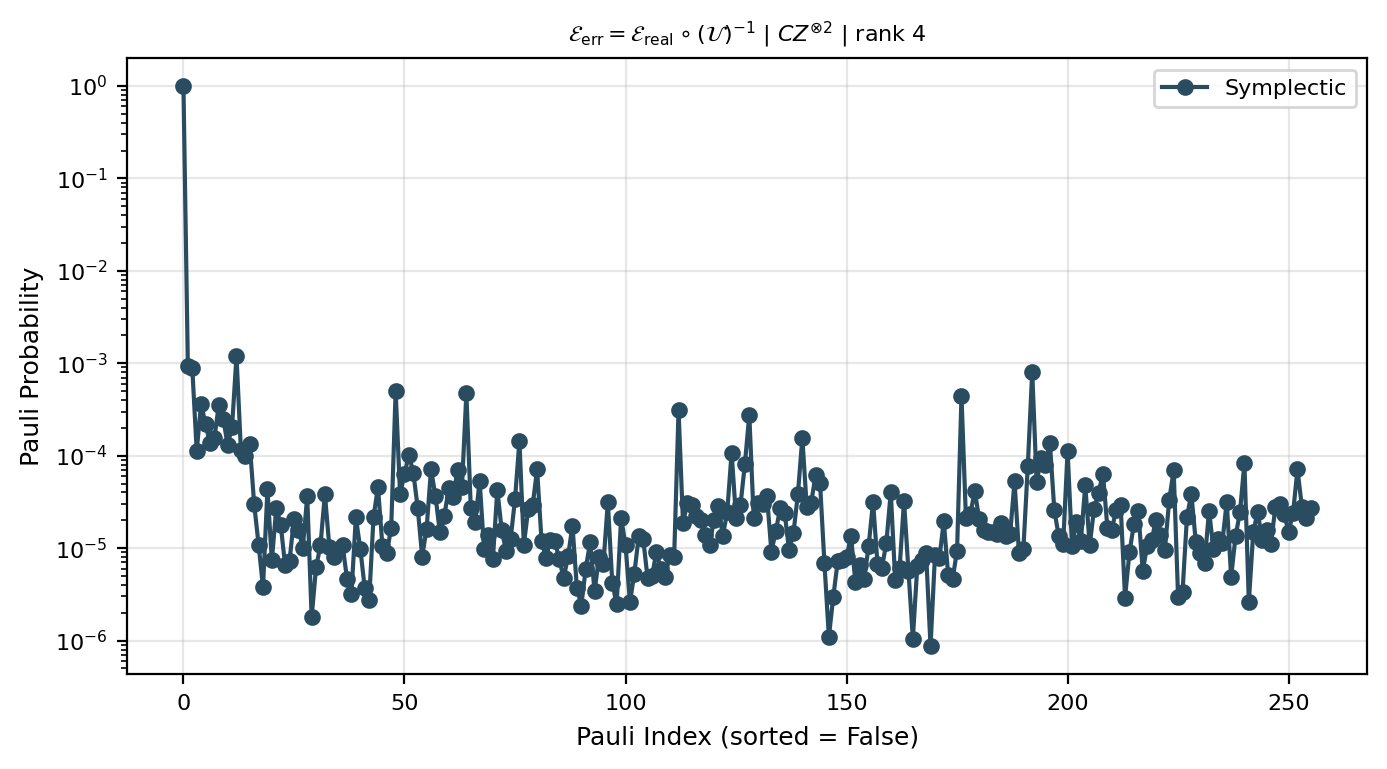

In [24]:
title_error = r"$\mathcal{E}_{\mathrm{err}}  = \mathcal{E}_{\mathrm{real}} \circ (\mathcal{U})^{-1} $ | $CZ^{\otimes 2}$ | rank 4"
fig_prob_error = plot_pauli_probabilities_indexed(probabilities={"Symplectic": probabilties_error}, title=title_error)

2026-04-09 17:12:58,272 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode
2026-04-09 17:12:58,276 - matplotlib.mathtext - INFO - Substituting symbol U from STIXNonUnicode
2026-04-09 17:12:58,336 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode
2026-04-09 17:12:58,341 - matplotlib.mathtext - INFO - Substituting symbol U from STIXNonUnicode


Sorting


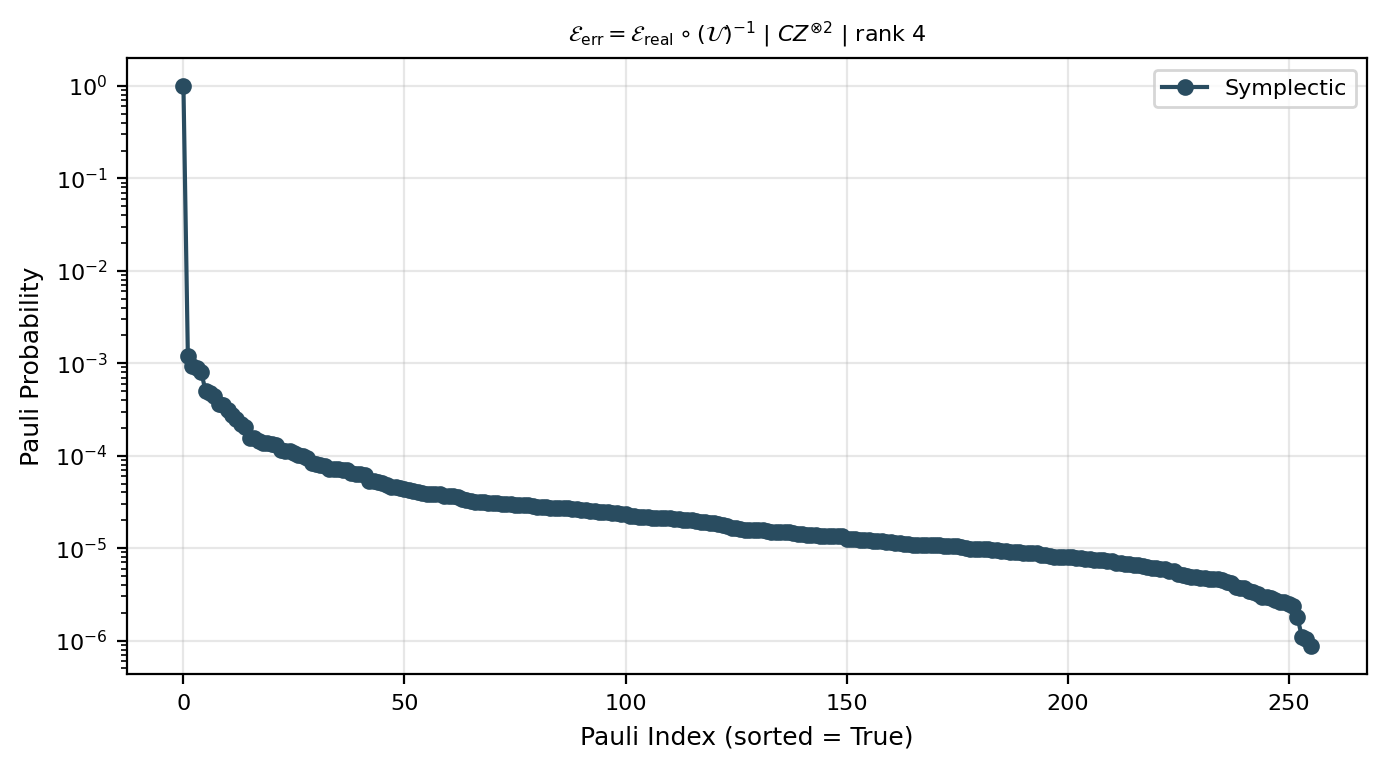

In [25]:
fig_prob_error_sorted = plot_pauli_probabilities_indexed(probabilities={"Symplectic": probabilties_error}, title=title_error, sort=True)

2026-04-09 17:13:13,438 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode
2026-04-09 17:13:13,443 - matplotlib.mathtext - INFO - Substituting symbol U from STIXNonUnicode
2026-04-09 17:13:13,501 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode
2026-04-09 17:13:13,505 - matplotlib.mathtext - INFO - Substituting symbol U from STIXNonUnicode


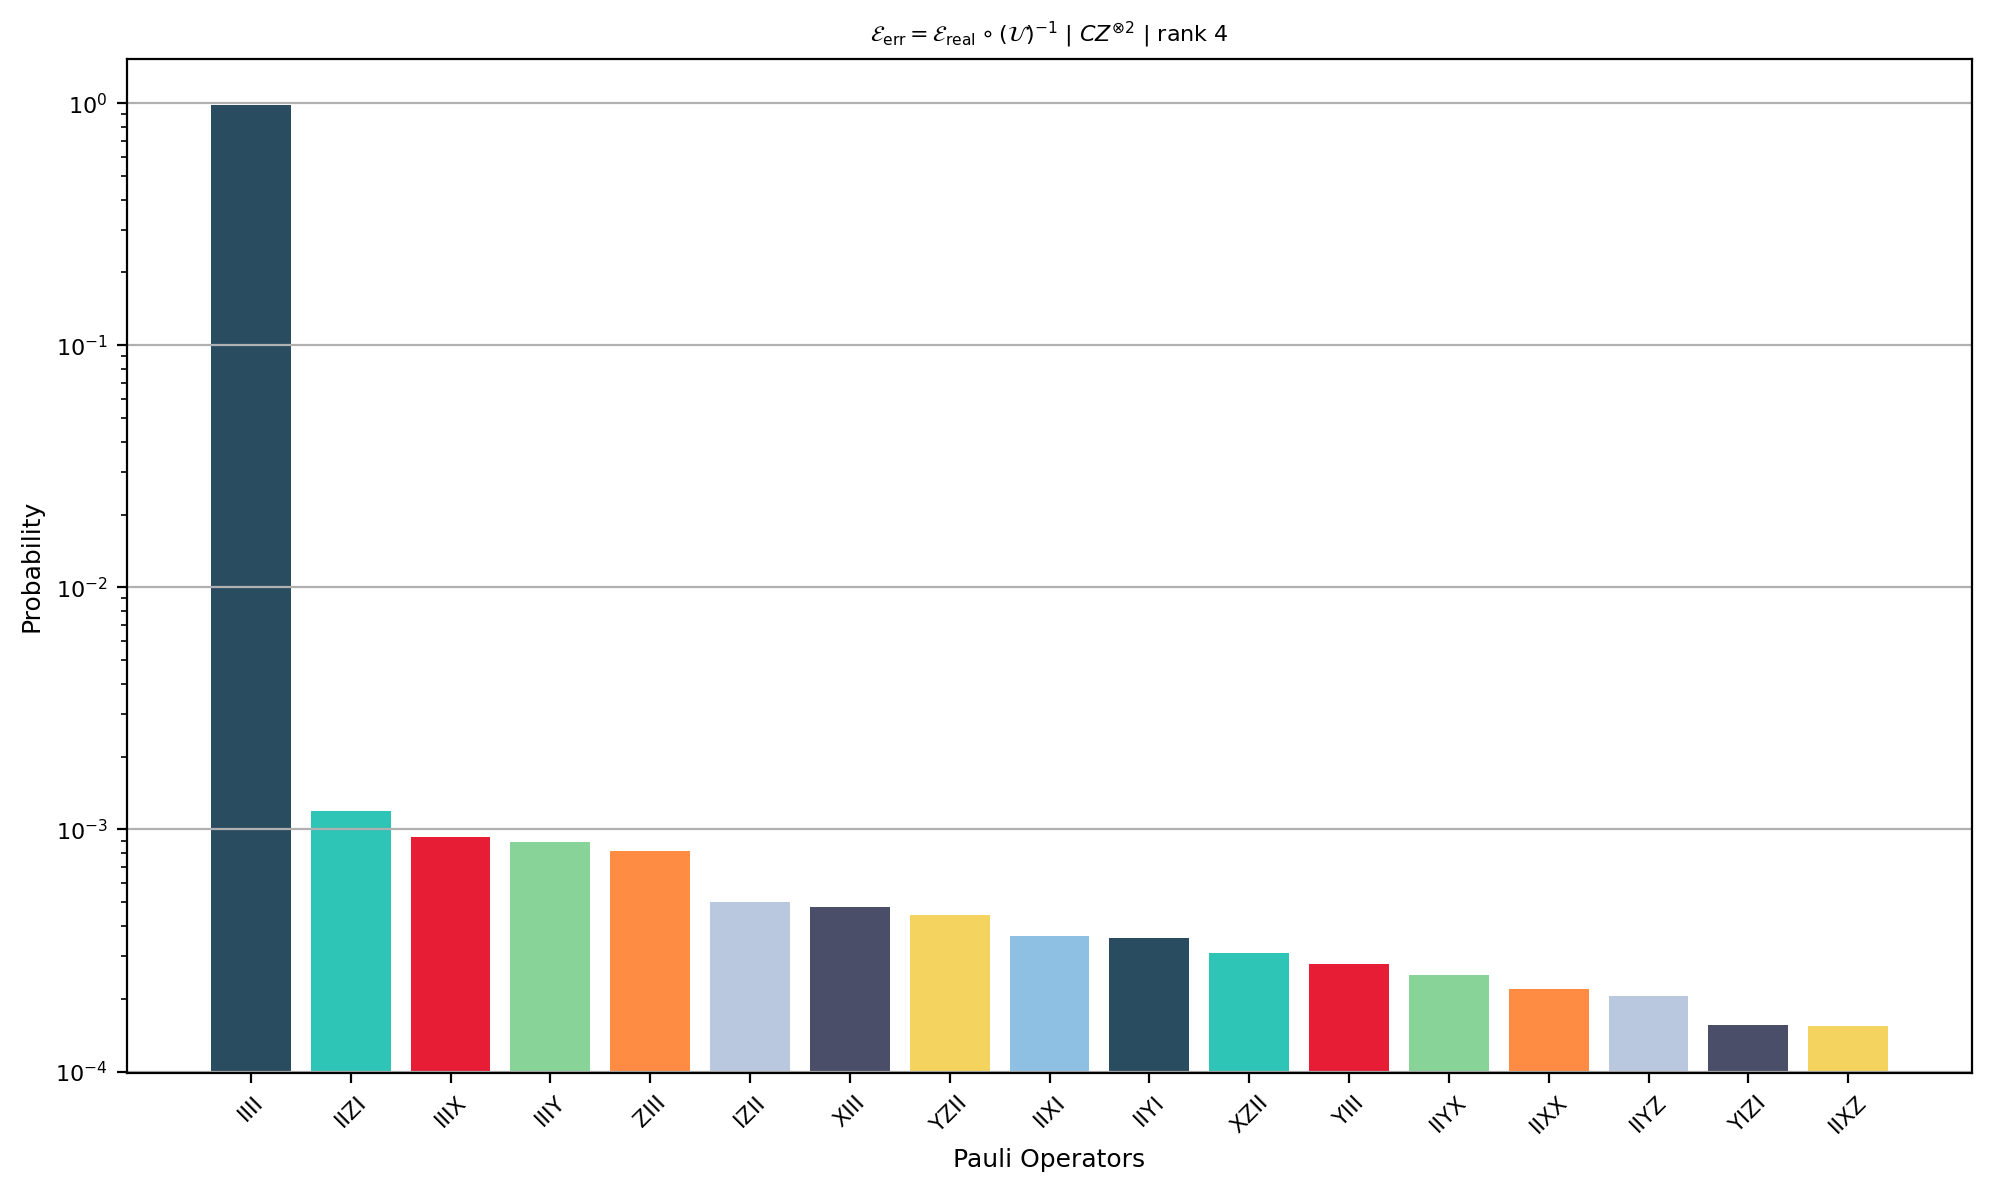

In [ ]:
fig_probs_labeled_error = plot_pauli_probabilities_labeled(probabilities=probabilities_dict_error, max_num_labels=17, log_scale=True, title=title_error)

2026-04-09 17:13:13,764 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode
2026-04-09 17:13:13,768 - matplotlib.mathtext - INFO - Substituting symbol U from STIXNonUnicode
2026-04-09 17:13:13,808 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode
2026-04-09 17:13:13,812 - matplotlib.mathtext - INFO - Substituting symbol U from STIXNonUnicode


Total probability: 1.0000000000000004


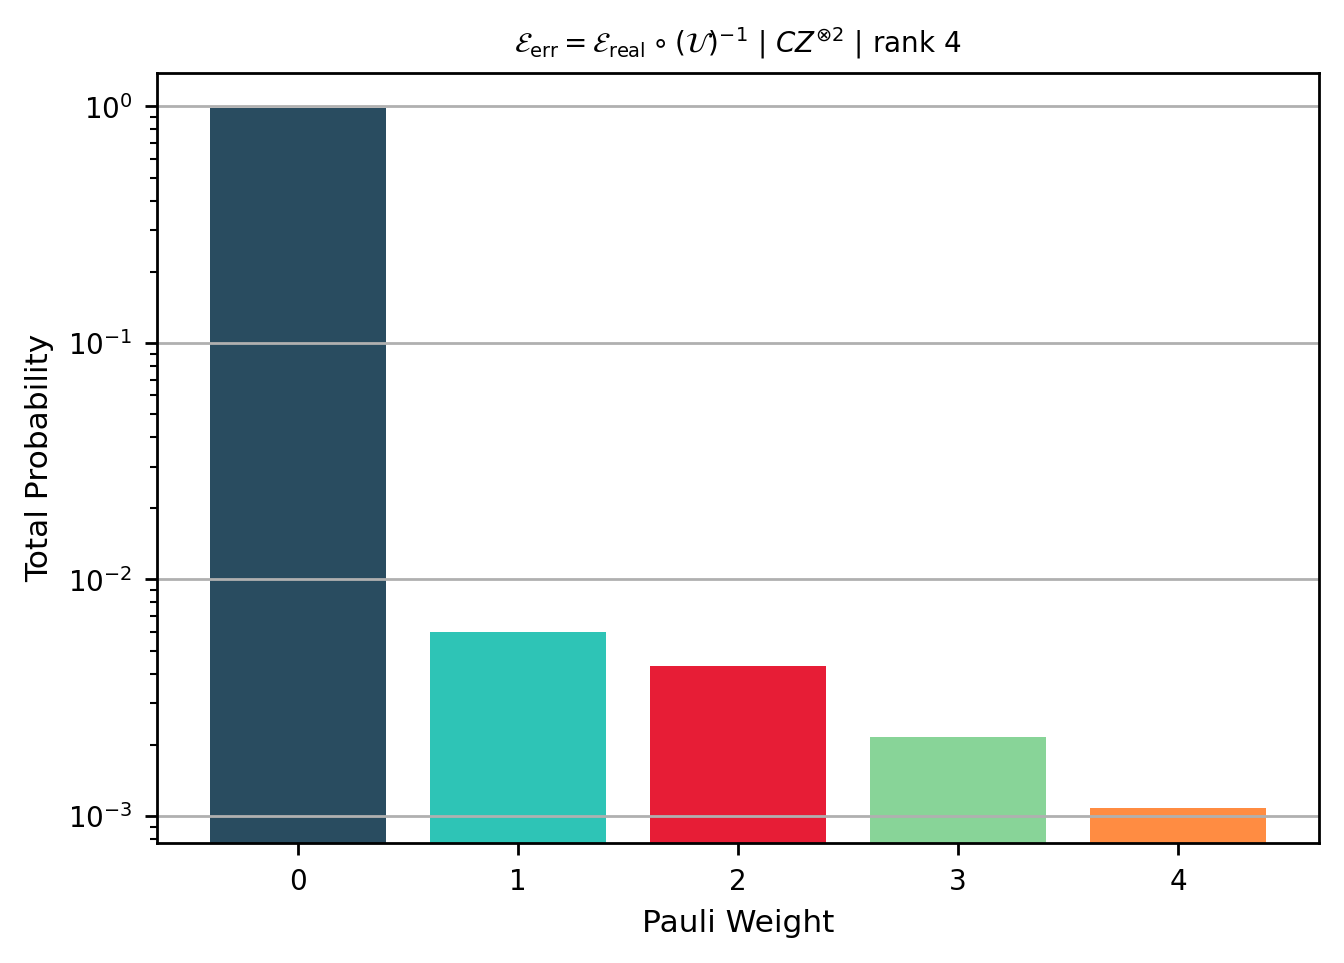

In [27]:
weights_error = weight_histogram(probabilities_dict_error, normalize=True)
fig_weight_error = plot_weight_histogram(weights_error, ascending=True, title=title_error)

2026-04-09 17:13:14,494 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode
2026-04-09 17:13:14,499 - matplotlib.mathtext - INFO - Substituting symbol U from STIXNonUnicode
2026-04-09 17:13:14,517 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode
2026-04-09 17:13:14,521 - matplotlib.mathtext - INFO - Substituting symbol U from STIXNonUnicode


Total probability: 0.013501385977892882


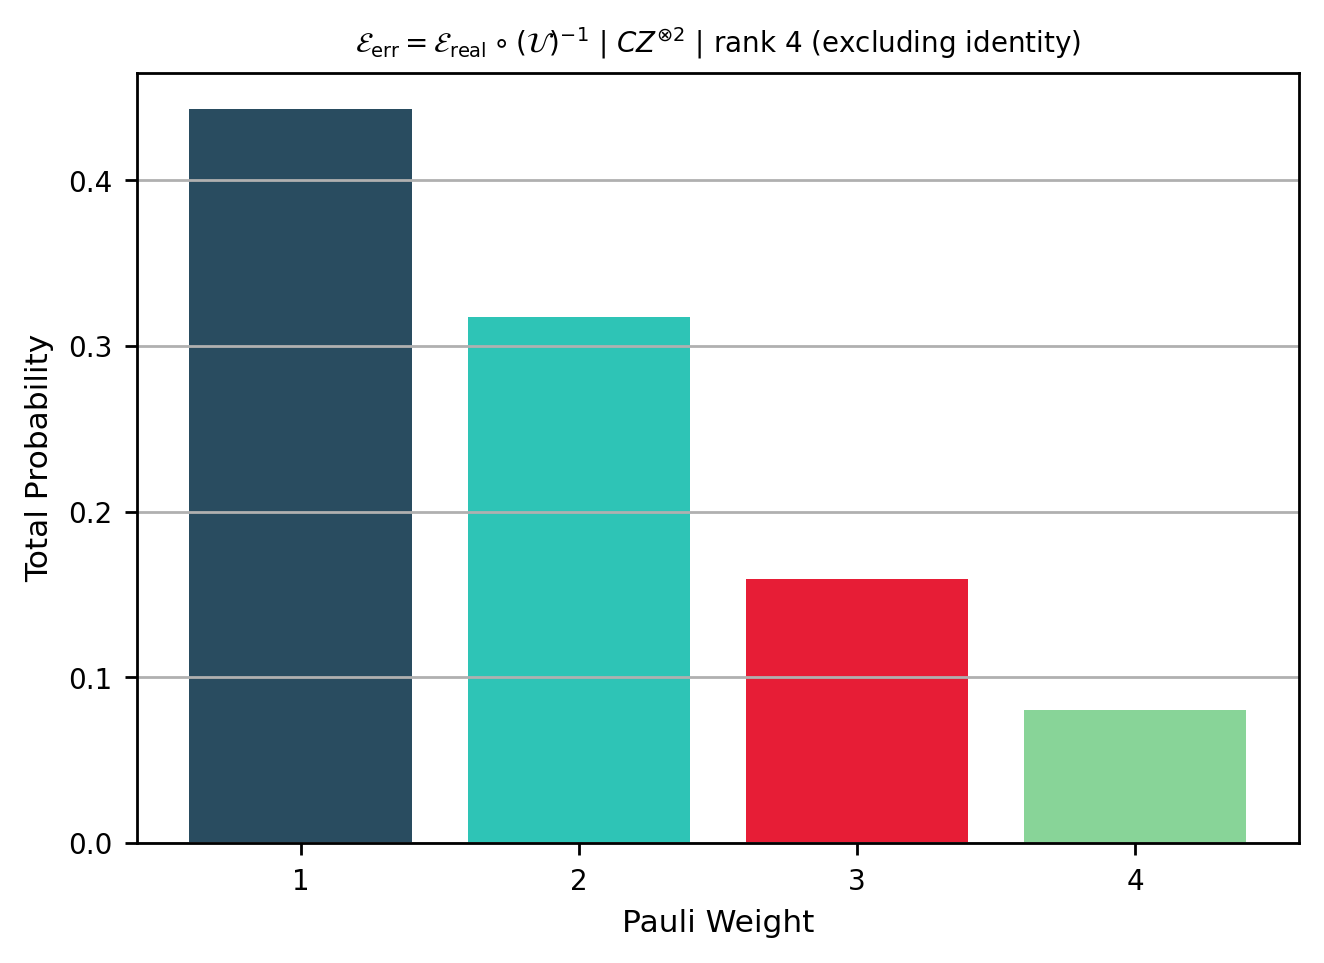

In [28]:
# look only at the error components.
title_only_error= title_error + " (excluding identity)"
weights_only_error = weight_histogram(probabilities_dict_error, normalize=True, exclude_identity=True)
fig_weight_only_error =plot_weight_histogram(weights_only_error, ascending=True, title=title_only_error, log_scale=False)

Total probability: 0.013501385977892882


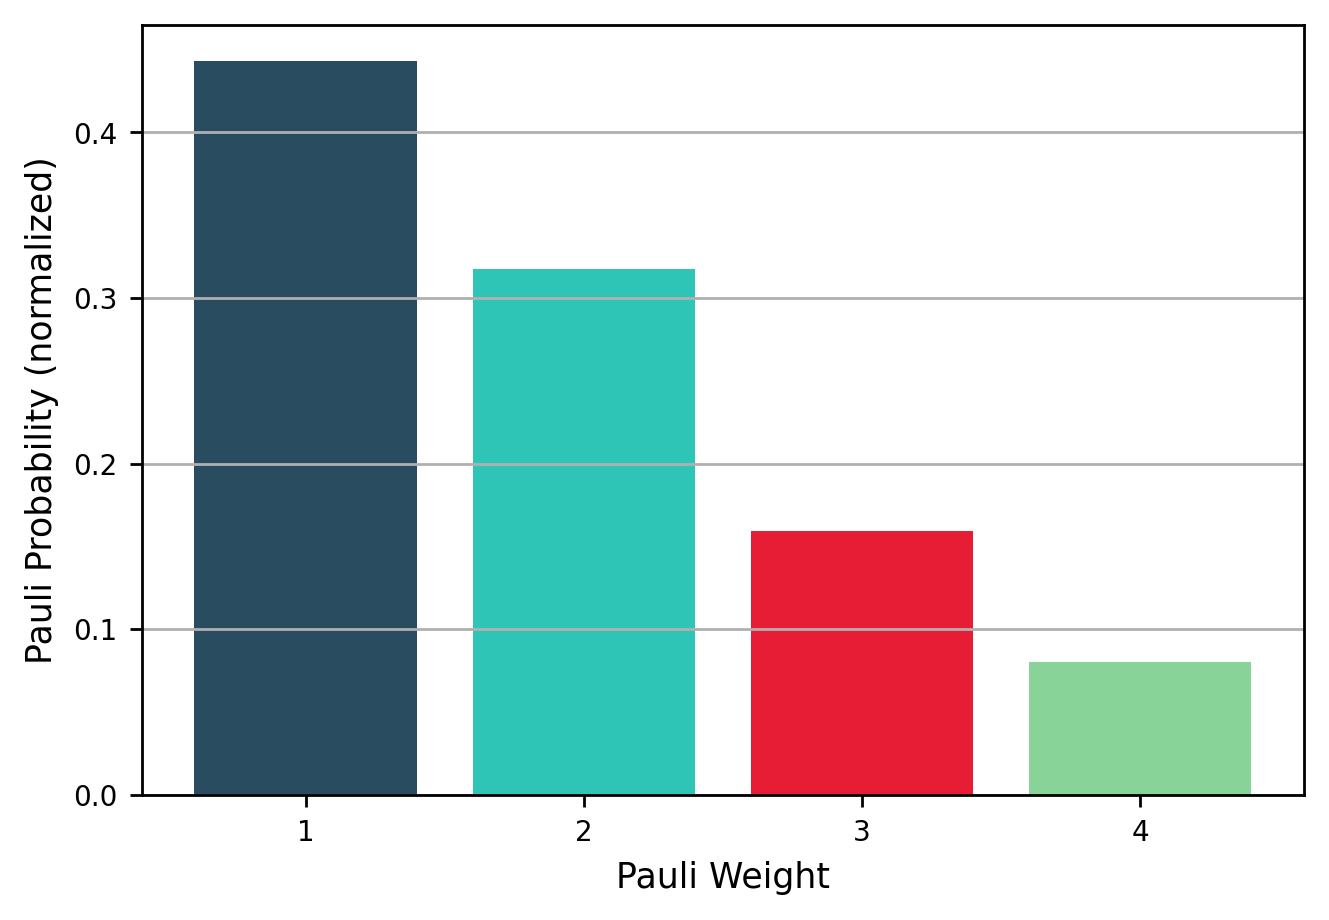

In [52]:
# title_only_error= title_error + " (excluding identity)"
weights_only_error = weight_histogram(probabilities_dict_error, normalize=True, exclude_identity=True)
fig_weight_only_error = plot_weight_histogram(weights_only_error, ascending=True, title=None, log_scale=False, ylabel="Pauli Probability (normalized)")

In [53]:
fig_weight_only_error.savefig("pauli_probability_vs_weight_normalized.pdf", dpi=300, bbox_inches="tight", transparent=True)

# Same analysis but on $\mathcal{E} - \mathbb{I}$

In [30]:
error_gen_approx = error_ptm - jnp.eye(dim**2)
eigvals_error_gen_approx = jnp.diag(error_gen_approx)
probs_dict_error_gen_approx = walsh_hadamard_transform_local_basis(eigvals_error_gen_approx.real, pauli_labels, check_normalization=False)
probabilties_error_gen_approx = jnp.array(list(probs_dict_error_gen_approx.values()))

2026-04-09 19:14:00,622 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode
2026-04-09 19:14:00,626 - matplotlib.mathtext - INFO - Substituting symbol I from STIXNonUnicode
2026-04-09 19:14:00,674 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode
2026-04-09 19:14:00,676 - matplotlib.mathtext - INFO - Substituting symbol I from STIXNonUnicode


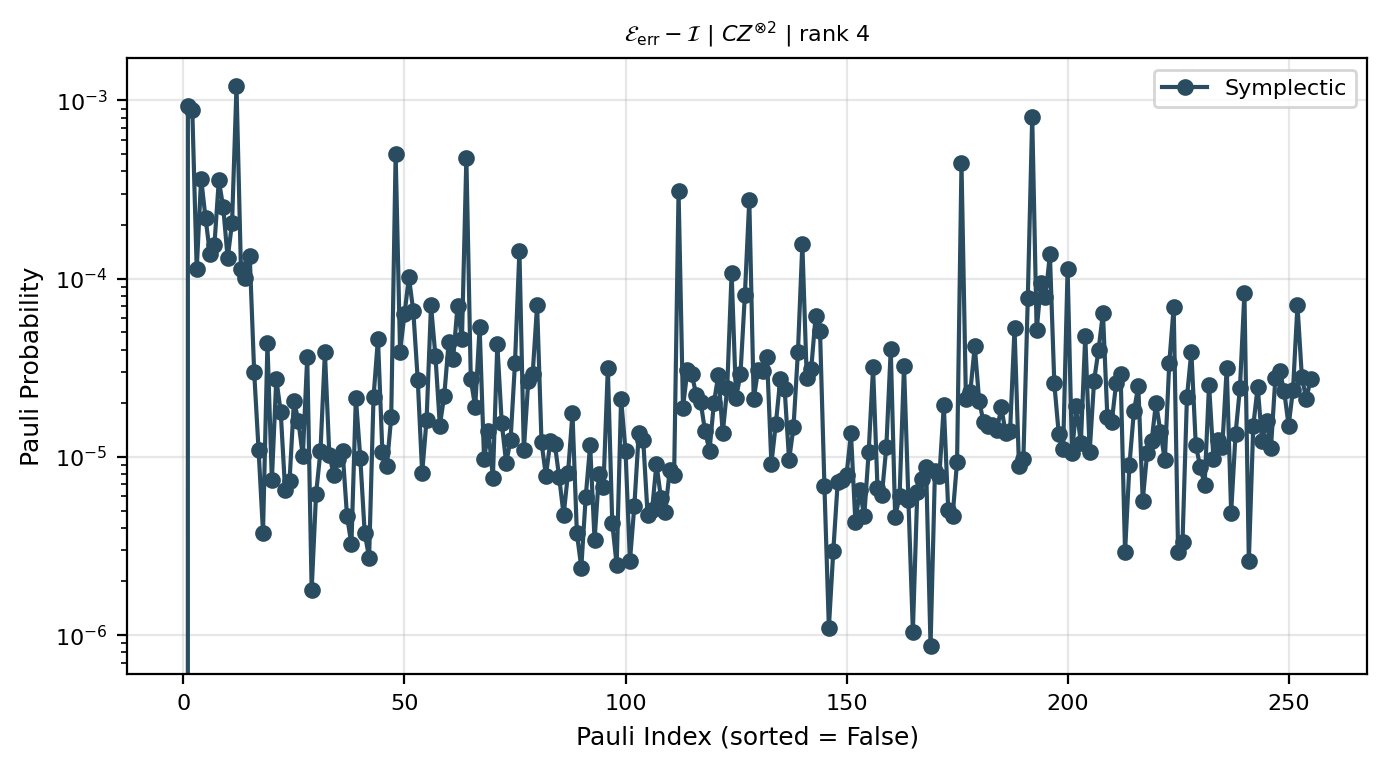

In [31]:
title_error_gen_approx = r"$\mathcal{E}_{\mathrm{err}} - \mathcal{I} $ | $CZ^{\otimes 2}$ | rank 4"
fig_prob_error_gen_approx = plot_pauli_probabilities_indexed(probabilities={"Symplectic": probabilties_error_gen_approx}, title=title_error_gen_approx)

2026-04-09 19:14:36,770 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode
2026-04-09 19:14:36,773 - matplotlib.mathtext - INFO - Substituting symbol I from STIXNonUnicode
2026-04-09 19:14:36,813 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode
2026-04-09 19:14:36,815 - matplotlib.mathtext - INFO - Substituting symbol I from STIXNonUnicode


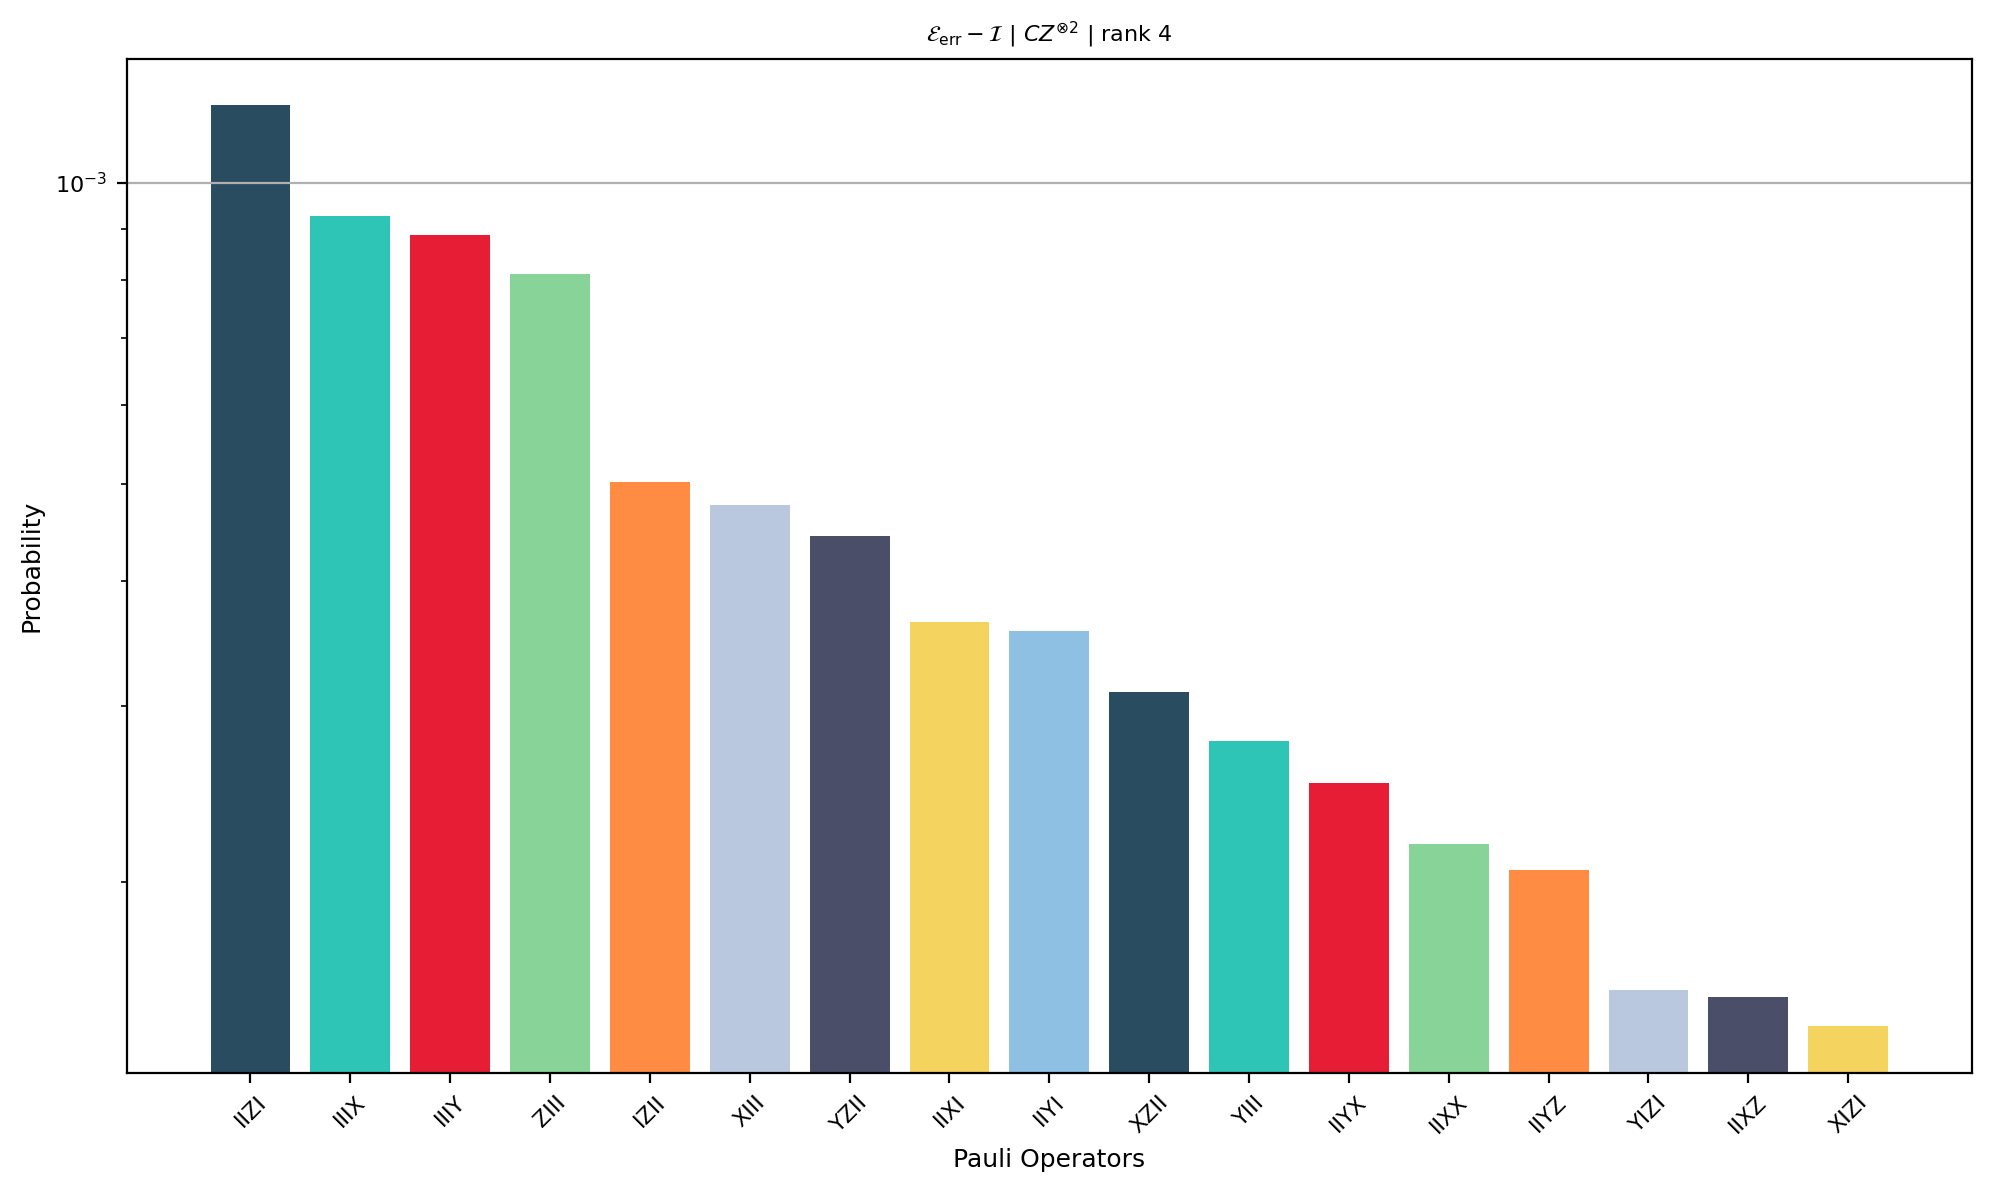

In [ ]:
fig_probs_labeled_error_gen_approx = plot_pauli_probabilities_labeled(probabilities=probs_dict_error_gen_approx, max_num_labels=17, log_scale=True, title=title_error_gen_approx)

In [37]:
probs_dict_error_gen_approx

{'IIII': Array(-0.01350139, dtype=float64),
 'IIIX': Array(0.00092699, dtype=float64),
 'IIIY': Array(0.00088587, dtype=float64),
 'IIIZ': Array(0.00011259, dtype=float64),
 'IIXI': Array(0.00036433, dtype=float64),
 'IIXX': Array(0.00021851, dtype=float64),
 'IIXY': Array(0.00013793, dtype=float64),
 'IIXZ': Array(0.00015351, dtype=float64),
 'IIYI': Array(0.00035642, dtype=float64),
 'IIYX': Array(0.00025122, dtype=float64),
 'IIYY': Array(0.00013004, dtype=float64),
 'IIYZ': Array(0.00020592, dtype=float64),
 'IIZI': Array(0.00119678, dtype=float64),
 'IIZX': Array(0.00011383, dtype=float64),
 'IIZY': Array(0.00010027, dtype=float64),
 'IIZZ': Array(0.00013318, dtype=float64),
 'IXII': Array(2.98849156e-05, dtype=float64),
 'IXIX': Array(1.0892934e-05, dtype=float64),
 'IXIY': Array(3.76142385e-06, dtype=float64),
 'IXIZ': Array(4.33231313e-05, dtype=float64),
 'IXXI': Array(7.3713057e-06, dtype=float64),
 'IXXX': Array(2.7330966e-05, dtype=float64),
 'IXXY': Array(1.79493666e-05, d

2026-04-09 19:17:39,936 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode
2026-04-09 19:17:39,942 - matplotlib.mathtext - INFO - Substituting symbol I from STIXNonUnicode
2026-04-09 19:17:39,964 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode
2026-04-09 19:17:39,968 - matplotlib.mathtext - INFO - Substituting symbol I from STIXNonUnicode


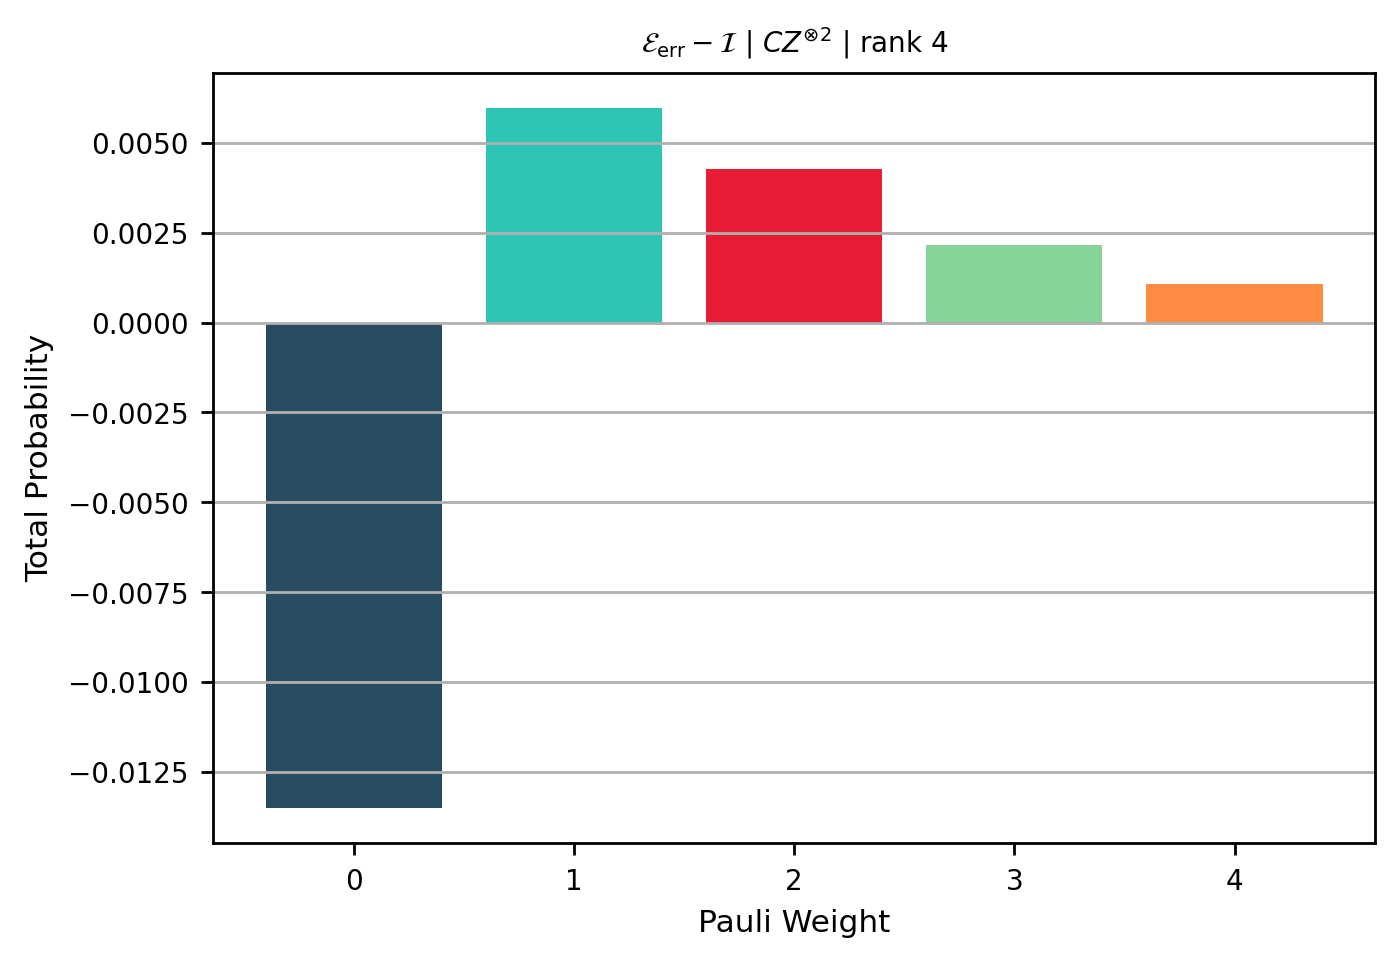

In [35]:
weights_error_gen_approx = weight_histogram(probs_dict_error_gen_approx, normalize=False)
# fig_weight_error_gen_approx = plot_weight_histogram(weights_error_gen_approx, ascending=True, title=title_error_gen_approx, log_scale=False)

In [36]:
weights_error_gen_approx

{0: Array(-0.01350139, dtype=float64),
 1: Array(0.00597836, dtype=float64),
 2: Array(0.00428637, dtype=float64),
 3: Array(0.00215444, dtype=float64),
 4: Array(0.00108221, dtype=float64)}

# Taxonomy (first attempt)